# Advanced Analytics + Risk Metrics

## Task 1: Historical VaR (95%) and CVaR

Objective:
- Compute Historical VaR (95%)
- Compute Conditional VaR (CVaR)
- Calculate for all 40 mutual fund schemes

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

## Load Required Datasets

In [24]:
returns = pd.read_csv("../data/processed/nav_daily_returns.csv")

returns.head()


,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [25]:
fund_master = pd.read_csv("../data/raw/Bluestock_MF_Datasets/01_fund_master.csv")

fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


## Merge Scheme Names

In [26]:
returns = returns.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

returns.head()

,amfi_code,date,nav,daily_return,scheme_name
0,100016,2022-01-03,520.4608,NaN,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,-0.010306,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,0.012865,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,-0.011377,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,-0.001210,HDFC Top 100 Fund - Regular Plan - Growth


In [27]:
returns = returns.dropna(subset=["daily_return"])

print(returns.shape)

(45960, 5)


## Calculate Historical VaR and CVaR

In [28]:
var_report = []

for scheme, df in returns.groupby("scheme_name"):

    daily_returns = df["daily_return"]

    var95 = np.percentile(daily_returns, 5)

    cvar95 = daily_returns[daily_returns <= var95].mean()

    var_report.append({
        "scheme_name": scheme,
        "VaR_95": round(var95, 6),
        "CVaR_95": round(cvar95, 6)
    })

In [29]:
var_cvar = pd.DataFrame(var_report)

var_cvar.head()

,scheme_name,VaR_95,CVaR_95
0,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
1,ABSL Liquid Fund - Regular - Growth,-0.000269,-0.000422
2,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
3,Axis Bluechip Fund - Direct - Growth,-0.014226,-0.017487
4,Axis Bluechip Fund - Regular - Growth,-0.013750,-0.017328


In [30]:
var_cvar = var_cvar.sort_values("VaR_95")

var_cvar

,scheme_name,VaR_95,CVaR_95
35,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384
6,Axis Small Cap Fund - Regular - Growth,-0.026188,-0.031667
2,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
31,Nippon India Small Cap Fund - Regular - Growth,-0.025438,-0.032304
36,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595
8,DSP Small Cap Fund - Regular - Growth,-0.023483,-0.031036
38,UTI Mid Cap Fund - Regular - Growth,-0.019220,-0.023251
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
18,ICICI Pru Midcap Fund - Regular - Growth,-0.018892,-0.024342
5,Axis Midcap Fund - Regular - Growth,-0.018480,-0.024260


In [31]:
var_cvar.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

print("✅ var_cvar_report.csv created successfully!")

✅ var_cvar_report.csv created successfully!


## Top 10 Highest Risk Funds

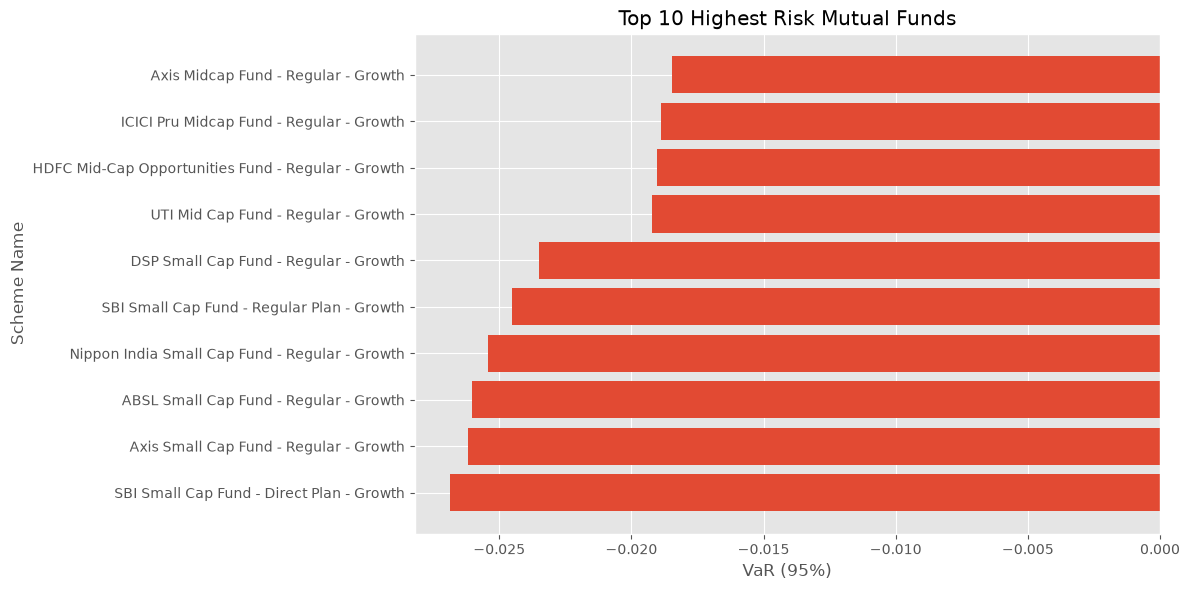

In [32]:
top10 = var_cvar.head(10)

plt.figure(figsize=(12,6))

plt.barh(top10["scheme_name"], top10["VaR_95"])

plt.xlabel("VaR (95%)")
plt.ylabel("Scheme Name")
plt.title("Top 10 Highest Risk Mutual Funds")

plt.tight_layout()

plt.show()

## Observations

- Historical VaR (95%) estimates the maximum expected daily loss with 95% confidence.
- CVaR measures the average loss during the worst 5% of trading days.
- Funds with more negative VaR and CVaR values have higher downside risk.

# Task 2: Rolling 90-Day Sharpe Ratio

### Objective
Calculate the 90-day rolling Sharpe Ratio for each mutual fund and visualize the performance of five key funds over time.

In [33]:
returns = returns.sort_values(["scheme_name", "date"])

returns.head()

,amfi_code,date,nav,daily_return,scheme_name
3451,101206,2022-01-04,305.4514,0.001153,ABSL Frontline Equity Fund - Regular - Growth
3452,101206,2022-01-05,306.6324,0.003866,ABSL Frontline Equity Fund - Regular - Growth
3453,101206,2022-01-06,305.9800,-0.002128,ABSL Frontline Equity Fund - Regular - Growth
3454,101206,2022-01-07,304.0480,-0.006314,ABSL Frontline Equity Fund - Regular - Growth
3455,101206,2022-01-10,307.5591,0.011548,ABSL Frontline Equity Fund - Regular - Growth


## Calculate Rolling Mean and Rolling Standard Deviation

In [34]:
rolling_list = []

In [35]:
for scheme, df in returns.groupby("scheme_name"):

    df = df.copy()

    df["rolling_mean"] = (
        df["daily_return"]
        .rolling(window=90)
        .mean()
    )

    df["rolling_std"] = (
        df["daily_return"]
        .rolling(window=90)
        .std()
    )

    rolling_list.append(df)

In [36]:
rolling_returns = pd.concat(
    rolling_list,
    ignore_index=True
)

rolling_returns.head()

,amfi_code,date,nav,daily_return,scheme_name,rolling_mean,rolling_std
0,101206,2022-01-04,305.4514,0.001153,ABSL Frontline Equity Fund - Regular - Growth,NaN,NaN
1,101206,2022-01-05,306.6324,0.003866,ABSL Frontline Equity Fund - Regular - Growth,NaN,NaN
2,101206,2022-01-06,305.9800,-0.002128,ABSL Frontline Equity Fund - Regular - Growth,NaN,NaN
3,101206,2022-01-07,304.0480,-0.006314,ABSL Frontline Equity Fund - Regular - Growth,NaN,NaN
4,101206,2022-01-10,307.5591,0.011548,ABSL Frontline Equity Fund - Regular - Growth,NaN,NaN


## Calculate Rolling Sharpe Ratio

In [37]:
rolling_returns["rolling_sharpe"] = (

    rolling_returns["rolling_mean"]

    /

    rolling_returns["rolling_std"]

) * np.sqrt(252)

rolling_returns.head()

,amfi_code,date,nav,daily_return,scheme_name,rolling_mean,rolling_std,rolling_sharpe
0,101206,2022-01-04,305.4514,0.001153,ABSL Frontline Equity Fund - Regular - Growth,NaN,NaN,NaN
1,101206,2022-01-05,306.6324,0.003866,ABSL Frontline Equity Fund - Regular - Growth,NaN,NaN,NaN
2,101206,2022-01-06,305.9800,-0.002128,ABSL Frontline Equity Fund - Regular - Growth,NaN,NaN,NaN
3,101206,2022-01-07,304.0480,-0.006314,ABSL Frontline Equity Fund - Regular - Growth,NaN,NaN,NaN
4,101206,2022-01-10,307.5591,0.011548,ABSL Frontline Equity Fund - Regular - Growth,NaN,NaN,NaN


In [38]:
rolling_returns.to_csv(

    "../data/processed/rolling_sharpe.csv",

    index=False

)

print("rolling_sharpe.csv created successfully")

rolling_sharpe.csv created successfully


## Select 5 Key Funds

In [39]:
returns["scheme_name"].unique()

<StringArray>
[        'ABSL Frontline Equity Fund - Regular - Growth',
                   'ABSL Liquid Fund - Regular - Growth',
                'ABSL Small Cap Fund - Regular - Growth',
                  'Axis Bluechip Fund - Direct - Growth',
                 'Axis Bluechip Fund - Regular - Growth',
                   'Axis Midcap Fund - Regular - Growth',
                'Axis Small Cap Fund - Regular - Growth',
                    'DSP Midcap Fund - Regular - Growth',
                 'DSP Small Cap Fund - Regular - Growth',
            'DSP Top 100 Equity Fund - Regular - Growth',
     'HDFC Mid-Cap Opportunities Fund - Direct - Growth',
    'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
          'HDFC Short Term Debt Fund - Regular - Growth',
              'HDFC Top 100 Fund - Direct Plan - Growth',
             'HDFC Top 100 Fund - Regular Plan - Growth',
             'ICICI Pru Bluechip Fund - Direct - Growth',
            'ICICI Pru Bluechip Fund - Regular - Growth',


## Plot Rolling 90-Day Sharpe Ratio for 5 Key Funds

In [40]:
top5_funds = [
    "Axis Bluechip Fund - Direct - Growth",
    "HDFC Top 100 Fund - Direct Plan - Growth",
    "ICICI Pru Bluechip Fund - Direct - Growth",
    "Kotak Bluechip Fund - Regular - Growth",
    "SBI Bluechip Fund - Regular Plan - Growth"
]

print(top5_funds)

['Axis Bluechip Fund - Direct - Growth', 'HDFC Top 100 Fund - Direct Plan - Growth', 'ICICI Pru Bluechip Fund - Direct - Growth', 'Kotak Bluechip Fund - Regular - Growth', 'SBI Bluechip Fund - Regular Plan - Growth']


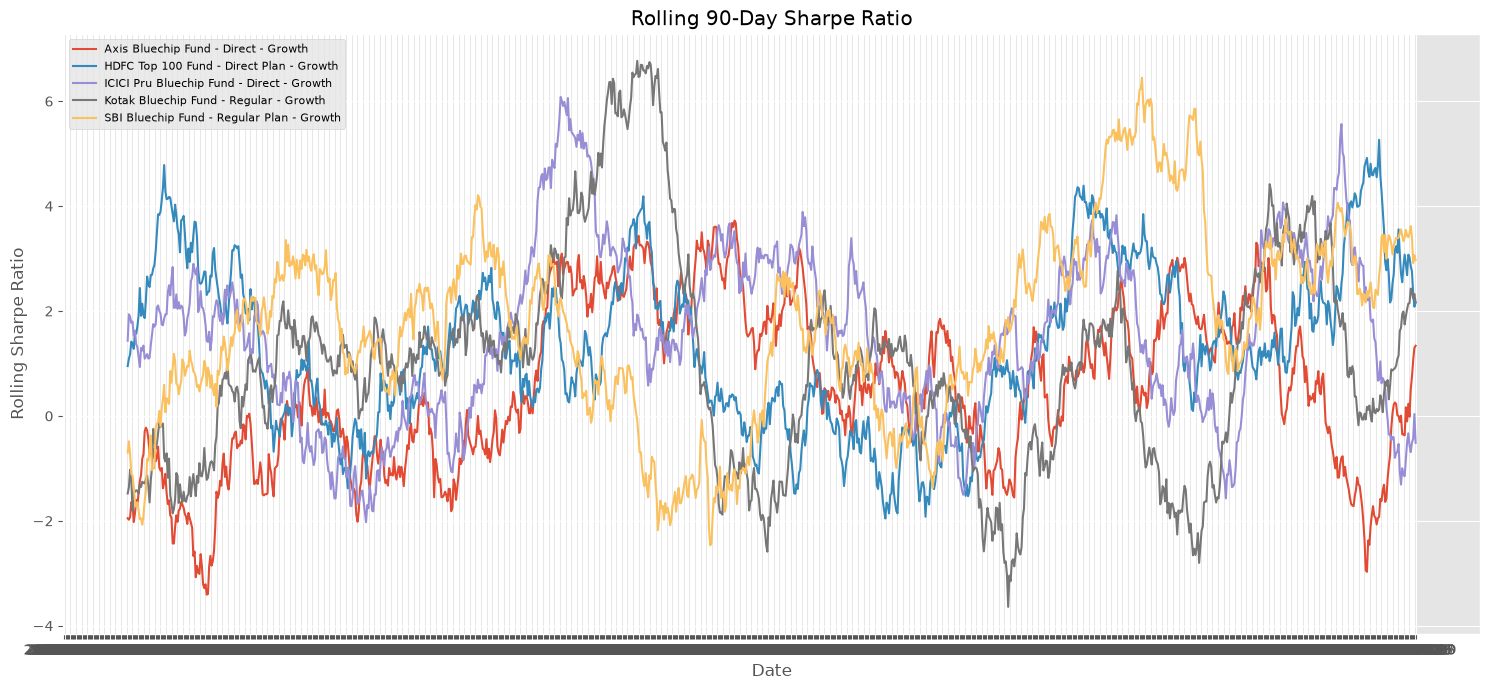

In [41]:
plt.figure(figsize=(15,7))

for fund in top5_funds:

    temp = rolling_returns[
        rolling_returns["scheme_name"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=fund
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend(fontsize=8)
plt.grid(True)

plt.tight_layout()

plt.show()

KeyboardInterrupt: 

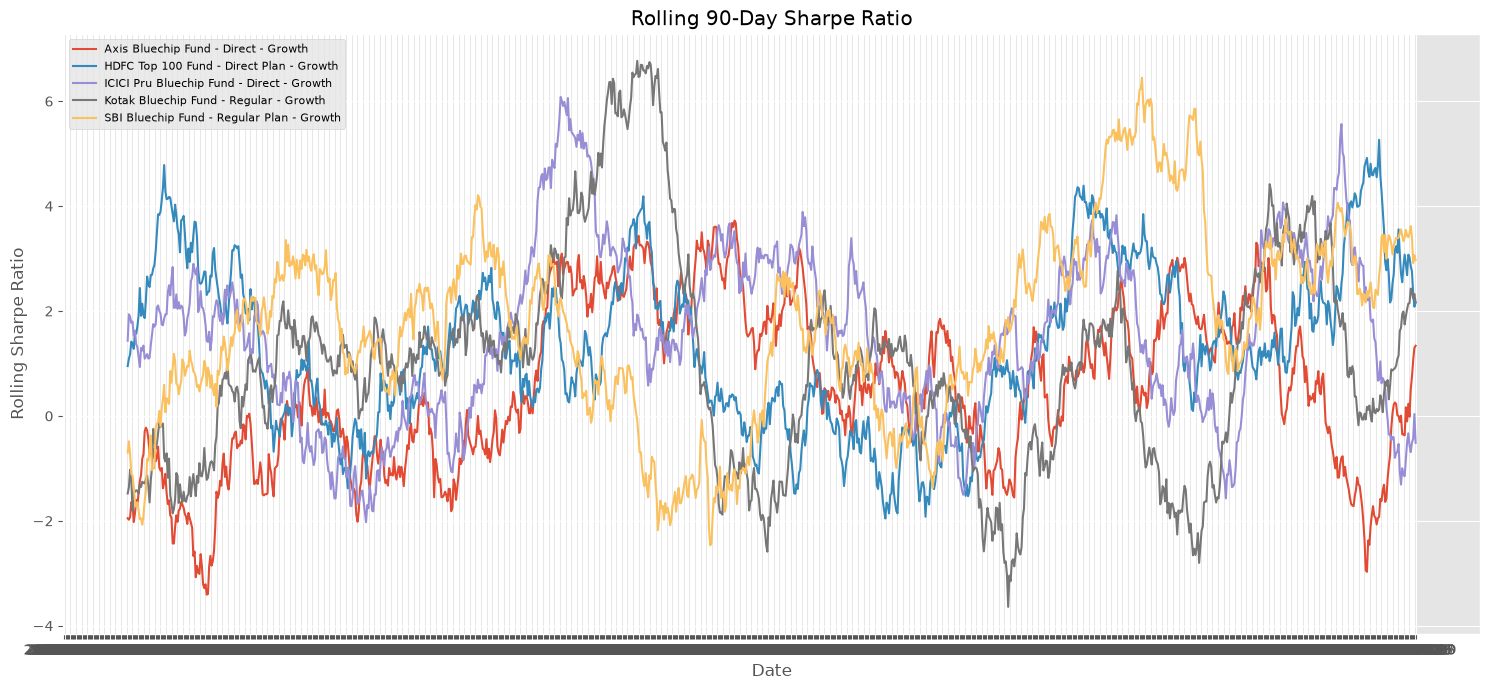

In [42]:
plt.figure(figsize=(15,7))

for fund in top5_funds:

    temp = rolling_returns[
        rolling_returns["scheme_name"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=fund
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend(fontsize=8)
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300
)

plt.show()

print("✅ rolling_sharpe_chart.png saved successfully!")

## Insights

- The Rolling 90-Day Sharpe Ratio measures the risk-adjusted performance using a moving 90-day window.
- A higher Sharpe Ratio indicates better returns for the level of risk taken.
- The chart compares how the risk-adjusted performance of five major mutual funds changes over time.
- Large fluctuations in the Sharpe Ratio indicate periods of higher market volatility.

# Task 3: Investor Cohort Analysis

In [ ]:
investor = pd.read_csv(
    "../data/raw/Bluestock_MF_Datasets/08_investor_transactions.csv"
)

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [ ]:
print(investor.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


## Prepare Investor Data

In [ ]:
investor["transaction_date"] = pd.to_datetime(investor["transaction_date"])

investor["transaction_year"] = investor["transaction_date"].dt.year

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


## Merge Scheme Names

In [ ]:
investor = investor.merge(

    fund_master[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year,scheme_name
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,Axis Bluechip Fund - Regular - Growth
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024,Mirae Asset Large Cap Fund - Regular - Growth
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024,Nippon India Gilt Securities Fund - Regular - ...
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024,Nippon India Small Cap Fund - Regular - Growth
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024,Axis Midcap Fund - Regular - Growth


## Find First Transaction Year (Investor Cohort)

In [ ]:
first_year = (

    investor.groupby("investor_id")["transaction_year"]

    .min()

    .reset_index()

    .rename(
        columns={
            "transaction_year":"cohort_year"
        }
    )

)

first_year.head()

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [ ]:
investor = investor.merge(

    first_year,

    on="investor_id",

    how="left"

)

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year,scheme_name,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,Axis Bluechip Fund - Regular - Growth,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024,Mirae Asset Large Cap Fund - Regular - Growth,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024,Nippon India Gilt Securities Fund - Regular - ...,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024,Nippon India Small Cap Fund - Regular - Growth,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024,Axis Midcap Fund - Regular - Growth,2024


## Average SIP Amount by Cohort

In [ ]:
avg_sip = (

    investor.groupby("cohort_year")["amount_inr"]

    .mean()

    .reset_index()

)

avg_sip.rename(

    columns={
        "amount_inr":"avg_sip_amount"
    },

    inplace=True

)

avg_sip

,cohort_year,avg_sip_amount
0,2024,107422.541832
1,2025,109158.577061


## Total Investment by Cohort

In [ ]:
total_investment = (

    investor.groupby("cohort_year")["amount_inr"]

    .sum()

    .reset_index()

)

total_investment.rename(

    columns={
        "amount_inr":"total_invested"
    },

    inplace=True

)

total_investment

,cohort_year,total_invested
0,2024,3491125187
1,2025,30455243


## Top Fund Preference by Cohort

In [ ]:
top_fund = (

    investor.groupby(
        ["cohort_year", "scheme_name"]
    )

    .size()

    .reset_index(name="count")

)

top_fund = (

    top_fund.sort_values(

        ["cohort_year", "count"],

        ascending=[True, False]

    )

    .drop_duplicates("cohort_year")

)

top_fund

,cohort_year,scheme_name,count
24,2024,Mirae Asset Emerging Bluechip Fund - Regular -...,874
57,2025,ICICI Pru Liquid Fund - Regular - Growth,12


## Final Investor Cohort Report

In [ ]:
cohort_report = (

    avg_sip

    .merge(
        total_investment,
        on="cohort_year"
    )

    .merge(
        top_fund[
            ["cohort_year", "scheme_name"]
        ],
        on="cohort_year"
    )

)

cohort_report

,cohort_year,avg_sip_amount,total_invested,scheme_name
0,2024,107422.541832,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,109158.577061,30455243,ICICI Pru Liquid Fund - Regular - Growth


In [ ]:
cohort_report.to_csv(

    "../data/processed/investor_cohort.csv",

    index=False

)

print("✅ investor_cohort.csv created successfully")

✅ investor_cohort.csv created successfully


# Task 4: SIP Continuity Analysis

### Objective

- Find investors with 6 or more SIP transactions.
- Calculate the average gap between consecutive SIP dates.
- Flag investors with an average gap greater than 35 days as "At Risk".

In [ ]:
sip = investor.copy()

sip["transaction_date"] = pd.to_datetime(sip["transaction_date"])

sip = sip.sort_values(["investor_id", "transaction_date"])

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year,scheme_name,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,ICICI Pru Midcap Fund - Regular - Growth,2024
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2025,Mirae Asset Tax Saver Fund - Regular - Growth,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2025,HDFC Top 100 Fund - Direct Plan - Growth,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,DSP Top 100 Equity Fund - Regular - Growth,2024
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024,DSP Midcap Fund - Regular - Growth,2024


## Keep Only SIP Transactions

In [ ]:
sip = sip[
    sip["transaction_type"].str.upper() == "SIP"
]

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year,scheme_name,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,ICICI Pru Midcap Fund - Regular - Growth,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2025,HDFC Top 100 Fund - Direct Plan - Growth,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,DSP Top 100 Equity Fund - Regular - Growth,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,Kotak Bluechip Fund - Regular - Growth,2024
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2025,Axis Midcap Fund - Regular - Growth,2024


## Investors with 6 or More SIP Transactions

In [ ]:
sip_count = (

    sip.groupby("investor_id")

    .size()

    .reset_index(name="sip_count")

)

eligible = sip_count[
    sip_count["sip_count"] >= 6
]

eligible.head()

,investor_id,sip_count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


In [ ]:
sip = sip.merge(
    eligible[["investor_id"]],
    on="investor_id",
    how="inner"
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year,scheme_name,cohort_year
0,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,ABSL Liquid Fund - Regular - Growth,2024
1,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,Axis Small Cap Fund - Regular - Growth,2024
2,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,Kotak Liquid Fund - Regular - Growth,2024
3,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,Mirae Asset Tax Saver Fund - Regular - Growth,2024
4,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2025,DSP Small Cap Fund - Regular - Growth,2024


## Calculate Gap Between Transactions

In [ ]:
sip["gap_days"] = (

    sip.groupby("investor_id")["transaction_date"]

    .diff()

    .dt.days

)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year,scheme_name,cohort_year,gap_days
0,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,ABSL Liquid Fund - Regular - Growth,2024,NaN
1,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,Axis Small Cap Fund - Regular - Growth,2024,26.0
2,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,Kotak Liquid Fund - Regular - Growth,2024,28.0
3,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,Mirae Asset Tax Saver Fund - Regular - Growth,2024,59.0
4,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2025,DSP Small Cap Fund - Regular - Growth,2024,265.0


## Average Gap Per Investor

In [ ]:
avg_gap = (

    sip.groupby("investor_id")["gap_days"]

    .mean()

    .reset_index()

)

avg_gap.rename(
    columns={
        "gap_days": "avg_gap_days"
    },
    inplace=True
)

avg_gap.head()

,investor_id,avg_gap_days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000


## Flag At-Risk Investors

In [ ]:
avg_gap["status"] = avg_gap["avg_gap_days"].apply(

    lambda x: "At Risk" if x > 35 else "Regular"

)

avg_gap.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [ ]:
avg_gap.to_csv(
    "../data/processed/sip_continuity.csv",
    index=False
)

print("✅ sip_continuity.csv created successfully")

✅ sip_continuity.csv created successfully


## Insights

- Investors with an average gap greater than 35 days are classified as **At Risk**.
- Investors with an average gap of 35 days or less are considered **Regular**.
- This analysis helps identify investors who may have interrupted or delayed their SIP contributions.

# Task 5: Simple Fund Recommender

### Objective

Recommend the **Top 3 Mutual Funds** based on:

- User Risk Appetite
  - Low
  - Moderate
  - High

Recommendation is based on the **highest Sharpe Ratio** within the matching risk category.

In [ ]:
import pandas as pd

fund_master = pd.read_csv("../data/raw/Bluestock_MF_Datasets/01_fund_master.csv")

sharpe = pd.read_csv("../data/processed/sharpe_ratio.csv")

## Merge Fund Information with Sharpe Ratio

In [ ]:
recommendation = fund_master.merge(
    sharpe,
    on="scheme_name",
    how="inner"
)

recommendation.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code,mean,std,sharpe_ratio
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,0.000917,0.008656,1.208267
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01,0.000785,0.008781,0.953279
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03,0.001201,0.015837,0.945308
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03,0.000201,0.015717,-0.057187
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02,0.000222,0.002499,-0.226575


In [ ]:
print(recommendation.columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code', 'mean', 'std', 'sharpe_ratio'],
      dtype='str')


In [ ]:
print(recommendation["risk_category"].unique())

<StringArray>
['Moderate', 'Very High', 'Low', 'High', 'Moderately High']
Length: 5, dtype: str


## Get User Risk Appetite

In [ ]:
risk = "moderate"      # change to "low" or "high" whenever needed

In [ ]:
if risk == "low":
    filtered = recommendation[
        recommendation["risk_category"] == "Low"
    ]

elif risk == "moderate":
    filtered = recommendation[
        recommendation["risk_category"].isin(
            ["Moderate", "Moderately High"]
        )
    ]

elif risk == "high":
    filtered = recommendation[
        recommendation["risk_category"].isin(
            ["High", "Very High"]
        )
    ]

else:
    print("Invalid Risk Level")
    filtered = pd.DataFrame()

In [ ]:
top3 = filtered.sort_values(
    by="sharpe_ratio",
    ascending=False
).head(3)

top3

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code,mean,std,sharpe_ratio
34,148567,Mirae Asset MF,Mirae Asset Large Cap Fund - Regular - Growth,Equity,Large Cap,Regular,2008-04-04,NIFTY 100 TRI,1.46,1.0,500,1000,Gaurav Misra,Moderate,EC01,0.001074,0.008941,1.448291
22,120843,Kotak Mahindra MF,Kotak Flexicap Fund - Regular - Growth,Equity,Flexi Cap,Regular,2009-08-11,NIFTY 500 TRI,1.45,1.0,500,1000,Pankaj Tibrewal,Moderately High,EC04,0.001082,0.010008,1.306744
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,0.000917,0.008656,1.208267


In [ ]:
print("="*70)
print("Top 3 Recommended Funds")
print("="*70)

print(
    top3[
        [
            "scheme_name",
            "risk_category",
            "sharpe_ratio"
        ]
    ]
)

Top 3 Recommended Funds
                                      scheme_name    risk_category  \
34  Mirae Asset Large Cap Fund - Regular - Growth         Moderate   
22         Kotak Flexicap Fund - Regular - Growth  Moderately High   
0       SBI Bluechip Fund - Regular Plan - Growth         Moderate   

    sharpe_ratio  
34      1.448291  
22      1.306744  
0       1.208267  


In [ ]:
recommendation_table = top3[
    [
        "scheme_name",
        "fund_house",
        "category",
        "risk_category",
        "sharpe_ratio"
    ]
]

recommendation_table

,scheme_name,fund_house,category,risk_category,sharpe_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,Moderate,1.448291
22,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,Moderately High,1.306744
0,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Moderate,1.208267


In [ ]:
recommendation_table.to_csv(
    "../data/processed/fund_recommendation.csv",
    index=False
)

print("✅ fund_recommendation.csv created successfully")

✅ fund_recommendation.csv created successfully


## Recommendation Logic

- User selects a risk appetite (Low, Moderate, or High).
- Funds are filtered based on the `risk_category`.
- Funds are ranked by `sharpe_ratio` in descending order.
- The top three funds are recommended.

# Task 6: Sector HHI Concentration

### Objective

Calculate the Herfindahl-Hirschman Index (HHI) for each equity mutual fund using portfolio holdings.

HHI = Σ(weight²)

Higher HHI indicates a more concentrated portfolio.

In [ ]:
portfolio = pd.read_csv(
    "../data/raw/Bluestock_MF_Datasets/09_portfolio_holdings.csv"
)

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


## Prepare Portfolio Weights

Convert portfolio weights from percentages to decimals for HHI calculation.

In [ ]:
portfolio["weight"] = portfolio["weight_pct"] / 100

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,weight
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,0.1385
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,0.1119
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,0.0990
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,0.0476
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,0.1025


## Calculate HHI for Each Fund

HHI = Σ(weight²)

In [ ]:
hhi = (

    portfolio.groupby("amfi_code")["weight"]

    .apply(lambda x: (x**2).sum())

    .reset_index()

)

hhi.rename(
    columns={"weight": "HHI"},
    inplace=True
)

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


## Merge Scheme Details

In [ ]:
hhi = hhi.merge(

    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "category"
        ]
    ],

    on="amfi_code",

    how="left"

)

hhi.head()

,amfi_code,HHI,scheme_name,category
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,Equity
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity


## Compare Equity Funds

In [ ]:
equity_hhi = hhi[
    hhi["category"] == "Equity"
].copy()

equity_hhi

,amfi_code,HHI,scheme_name,category
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,Equity
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity
5,102886,0.114693,UTI Mid Cap Fund - Regular - Growth,Equity
6,102887,0.129805,UTI Flexi Cap Fund - Regular - Growth,Equity
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity
8,118633,0.121461,Nippon India Large Cap Fund - Direct - Growth,Equity
9,118634,0.108358,Nippon India Small Cap Fund - Regular - Growth,Equity


In [ ]:
equity_hhi = equity_hhi.sort_values(
    by="HHI",
    ascending=False
)

equity_hhi.head(10)

,amfi_code,HHI,scheme_name,category
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Equity
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Equity


## HHI Interpretation

In [ ]:
def classify_hhi(x):

    if x >= 0.18:
        return "Highly Concentrated"

    elif x >= 0.10:
        return "Moderately Concentrated"

    else:
        return "Well Diversified"


equity_hhi["HHI_Level"] = equity_hhi["HHI"].apply(classify_hhi)

equity_hhi.head()

,amfi_code,HHI,scheme_name,category,HHI_Level
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Equity,Highly Concentrated
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity,Highly Concentrated
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Equity,Moderately Concentrated
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity,Moderately Concentrated
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity,Moderately Concentrated


In [ ]:
equity_hhi.to_csv(
    "../data/processed/sector_hhi.csv",
    index=False
)

print("✅ sector_hhi.csv created successfully")

✅ sector_hhi.csv created successfully


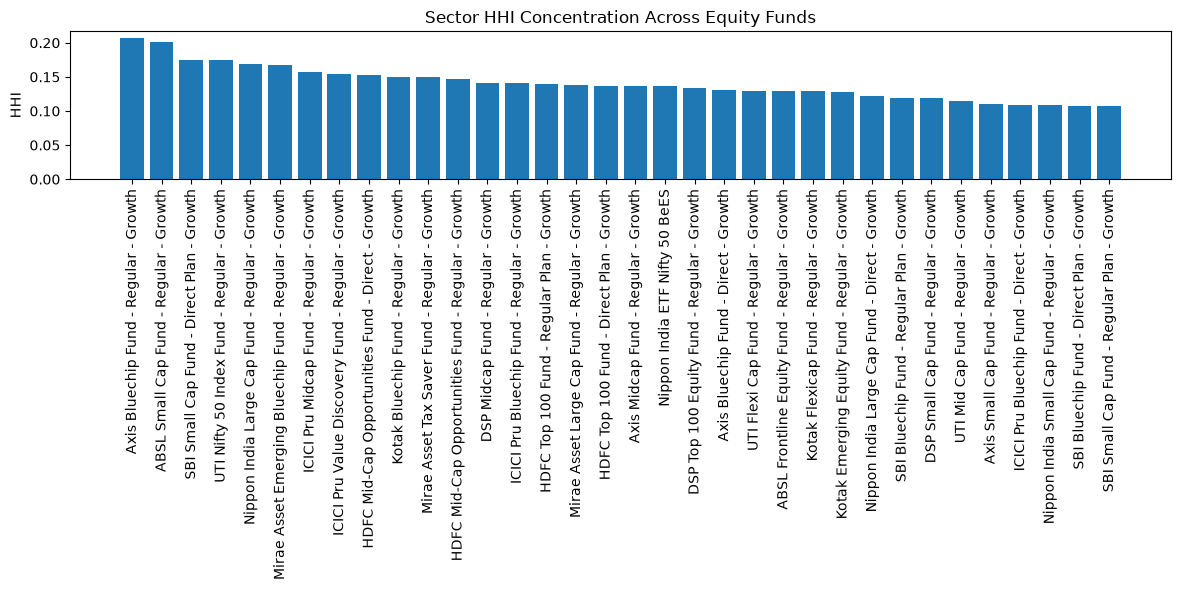

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    equity_hhi["scheme_name"],
    equity_hhi["HHI"]
)

plt.xticks(rotation=90)

plt.ylabel("HHI")

plt.title("Sector HHI Concentration Across Equity Funds")

plt.tight_layout()

plt.savefig(
    "../reports/sector_hhi_chart.png",
    dpi=300
)

plt.show()

## Insights

- Higher HHI indicates that a fund's portfolio is concentrated in a few holdings.
- Lower HHI indicates better diversification across holdings.
- Comparing HHI across equity funds helps identify concentration risk.

# Advanced Insights

## 1. Risk Analysis (VaR & CVaR)

- Historical VaR (95%) identifies the maximum expected one-day loss under normal market conditions.
- Funds with larger negative VaR values exhibit higher downside risk.
- CVaR provides the average loss during the worst 5% of trading days, making it a better measure of tail risk than VaR.

---

## 2. Rolling Sharpe Ratio

- The 90-day Rolling Sharpe Ratio shows how risk-adjusted performance changes over time.
- Funds with consistently higher rolling Sharpe ratios delivered superior returns relative to their volatility.
- Large fluctuations in the rolling Sharpe ratio indicate periods of increased market uncertainty.

---

## 3. Investor Cohort Analysis

- Investors were grouped based on their first investment year.
- The 2024 cohort contributed the highest total investment and average SIP amount compared to the 2025 cohort.
- The most preferred mutual fund for each cohort was identified based on transaction frequency.

---

## 4. SIP Continuity Analysis

- Investors with an average gap greater than 35 days between SIP transactions were classified as **At Risk**.
- The analysis helps identify investors who may discontinue or delay their SIP investments.
- Regular investors maintained consistent investment intervals and are less likely to lapse.

---

## 5. Portfolio Concentration (HHI)

- The Herfindahl-Hirschman Index (HHI) measures portfolio concentration using holding weights.
- Equity funds with higher HHI values are more concentrated in a few holdings, increasing concentration risk.
- Funds with lower HHI values are better diversified and generally have lower concentration risk.